# 01 — Dataset Exploration: MVTec AD (bottle)

Verifies the downloaded dataset against documented statistics, visualizes
sample images from each class, inspects pixel-value distributions, and
confirms the leakage-safe split logic in `src/data/dataset.py` behaves as
documented before any model training begins.

**Prerequisite:** MVTec AD `bottle` downloaded per `data/README.md`.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from src.data.dataset import build_samples, verify_download

DATA_ROOT='../data/mvtec_ad'
CATEGORY='bottle'

## 1. Verify the download matches documented statistics

In [2]:
verify_download(DATA_ROOT, CATEGORY)

Verifying: ..\data\mvtec_ad\bottle
[OK] train/good: found 209, expected 209
[OK] test/good: found 20, expected 20
[OK] test/broken_large: found 20, expected 20
[OK] test/broken_small: found 22, expected 22
[OK] test/contamination: found 21, expected 21
[OK] ground_truth directory present: ..\data\mvtec_ad\bottle\ground_truth

All checks passed. Dataset is ready.


## 2. Sample images from each class

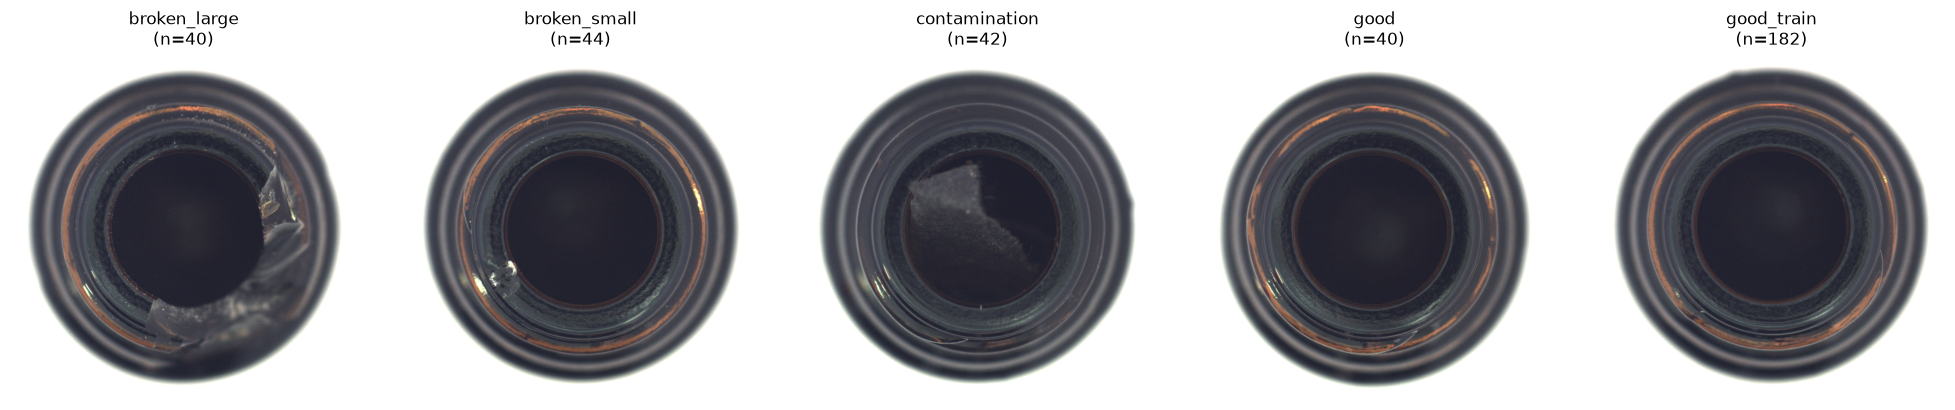

In [3]:
train_good=build_samples(DATA_ROOT, CATEGORY, 'ae_train')
test_samples=build_samples(DATA_ROOT, CATEGORY, 'labeled_val', val_fraction=1.0)\
    +build_samples(DATA_ROOT, CATEGORY, 'labeled_test', val_fraction=0.0)

by_type={}
for s in test_samples:
    by_type.setdefault(s.defect_type, []).append(s)
by_type['good_train']=train_good

fig, axes=plt.subplots(1, len(by_type), figsize=(4 * len(by_type), 4))
for ax, (defect_type, samples) in zip(axes, by_type.items()):
    img=Image.open(samples[0].image_path)
    ax.imshow(img)
    ax.set_title(f'{defect_type}\n(n={len(samples)})')
    ax.axis('off')
plt.tight_layout()
plt.savefig('../results/plots/sample_images_per_class.png', dpi=120)
plt.show()

## 3. Ground-truth defect masks overlaid on defective images

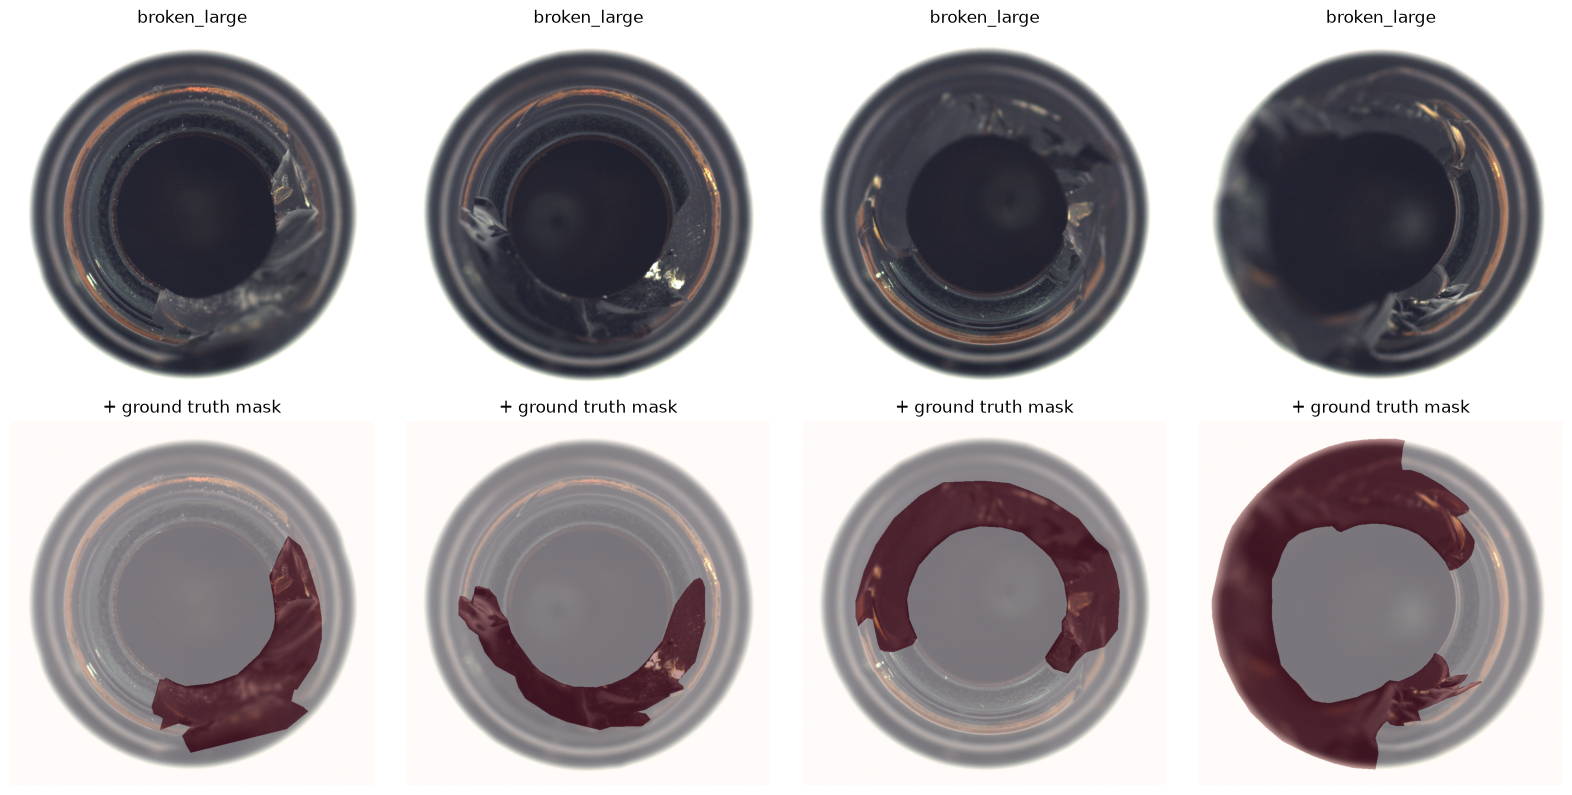

In [4]:
defective_with_masks=[s for s in test_samples if s.mask_path is not None]
n_show=min(4, len(defective_with_masks))

fig, axes=plt.subplots(2, n_show, figsize=(4 * n_show, 8))
for i, sample in enumerate(defective_with_masks[:n_show]):
    img = Image.open(sample.image_path)
    mask = Image.open(sample.mask_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(sample.defect_type)
    axes[0, i].axis('off')
    axes[1, i].imshow(img)
    axes[1, i].imshow(mask, cmap='Reds', alpha=0.4)
    axes[1, i].set_title('+ ground truth mask')
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('../results/plots/ground_truth_masks.png', dpi=120)
plt.show()

## 4. Class balance across splits

In [5]:
labels=['ae_train\n(normal only)']
counts=[len(build_samples(DATA_ROOT, CATEGORY, 'ae_train'))]

for split in ['labeled_val', 'labeled_test']:
    samples=build_samples(DATA_ROOT, CATEGORY, split, val_fraction=0.3)
    n_normal=sum(1 for s in samples if s.label == 0)
    n_defective=sum(1 for s in samples if s.label == 1)
    print(f'{split}: {n_normal} normal, {n_defective} defective (total {len(samples)})')

labeled_val: 7 normal, 21 defective (total 28)
labeled_test: 13 normal, 42 defective (total 55)


## Observations from the real MVTec AD bottle dataset

- **Dataset counts confirmed.** The local `bottle` dataset matches the expected counts:
  - Train/good: 209 images
  - Test/good: 20 images
  - Test/broken_large: 20 images
  - Test/broken_small: 22 images
  - Test/contamination: 21 images
  - Total: 292 images

- **Defect subtype characteristics.**
  - `broken_large`: large structural breaks are generally more prominent and easier to distinguish from normal bottles.
  - `broken_small`: smaller structural defects are more localized and can be visually subtle.
  - `contamination`: contamination appears as localized visual irregularities and can vary in size, contrast, and position.

- **Visual subtlety.** Not all defects are equally obvious. `broken_large` defects are generally easier to identify, while `broken_small` and some contamination cases can be more subtle. This supports using moderate augmentation and sufficient image resolution so that small localized defects are not lost during preprocessing.